In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier



# %matplotlib inline


## 1. Análise exploratória

In [4]:
df = pd.read_csv('../data/raw/ai4i2020.csv')

In [5]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [7]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [8]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [9]:
df['Machine failure'].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

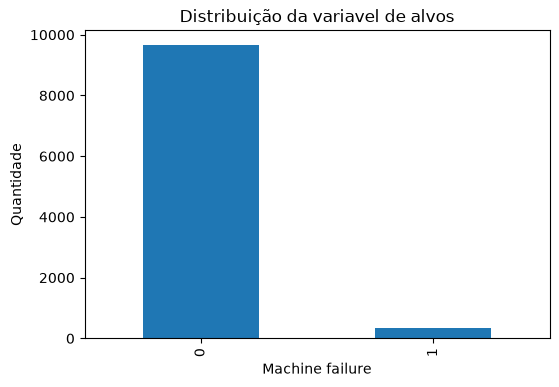

In [10]:
df['Machine failure'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)


plt.title('Distribuição da variavel de alvos')
plt.xlabel('Machine failure')
plt.ylabel('Quantidade')
plt.show()

In [11]:
correlation = df.corr(numeric_only=True)

correlation 

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,1.000000,0.117428,0.324428,-0.006615,0.003207,-0.010702,-0.022892,0.009154,-0.022215,-0.023557,-0.000990,-0.005954
Air temperature [K],0.117428,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,0.009955,0.137831,0.003470,0.001988,0.017688
Process temperature [K],0.324428,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,0.007315,0.056933,-0.003355,0.004554,0.022279
Rotational speed [rpm],-0.006615,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,0.010389,-0.121241,0.123018,-0.104575,-0.013088
Torque [Nm],0.003207,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.014662,0.142610,0.083781,0.183465,0.016136
Tool wear [min],-0.010702,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,0.115792,-0.001287,-0.009334,0.155894,0.011326
Machine failure,-0.022892,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516
TWF,0.009154,0.009955,0.007315,0.010389,-0.014662,0.115792,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970
HDF,-0.022215,0.137831,0.056933,-0.121241,0.142610,-0.001287,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706
PWF,-0.023557,0.003470,-0.003355,0.123018,0.083781,-0.009334,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273


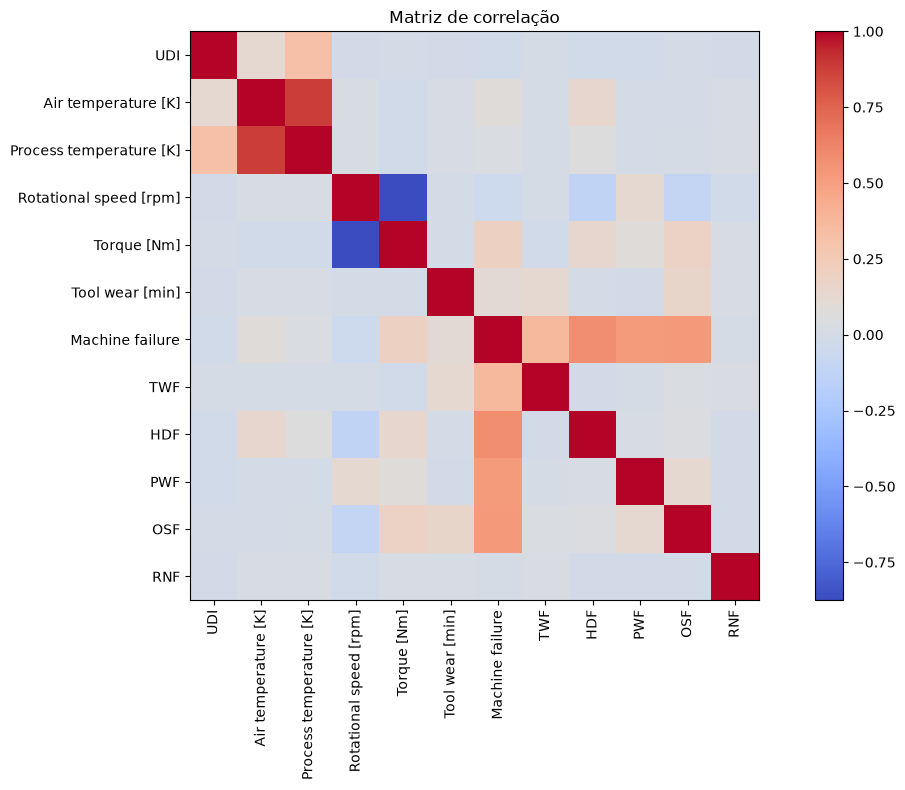

In [12]:
plt.figure(figsize=(12, 8))

plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title('Matriz de correlação')
plt.tight_layout()

plt.show()

# 1.1 Distribuição das variáveis

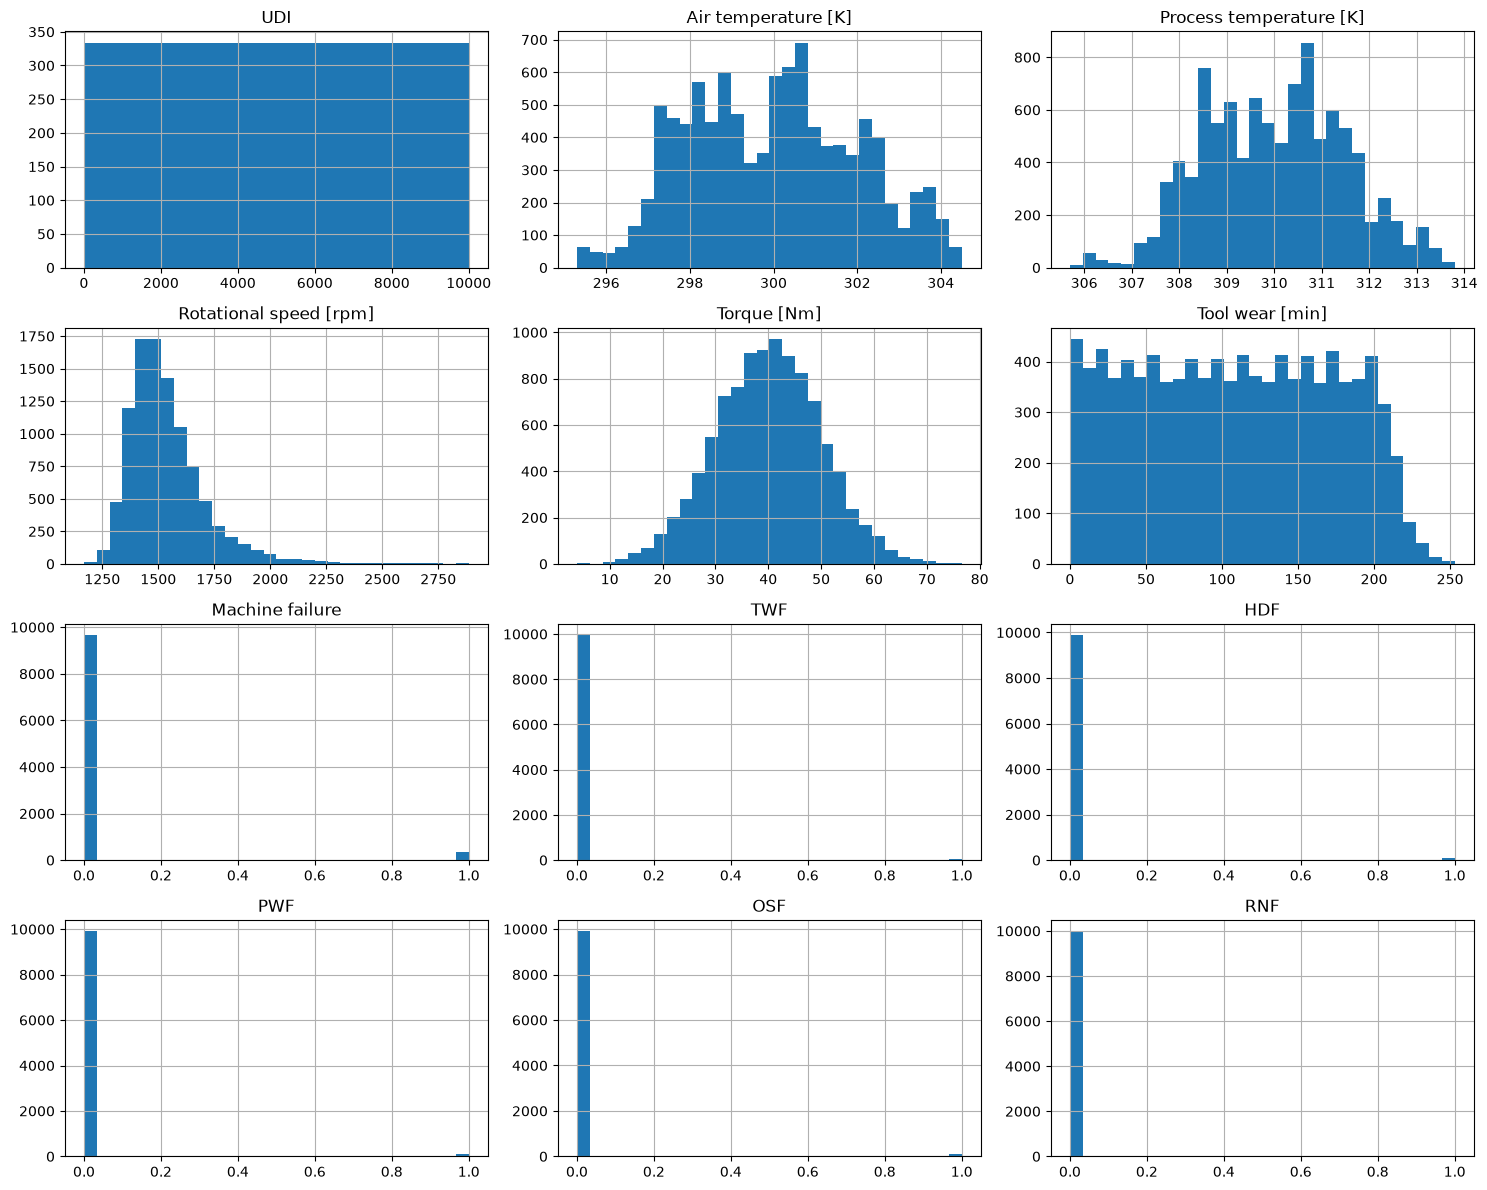

In [13]:
numeric_columns = df.select_dtypes(include='number').columns

df[numeric_columns].hist(
    figsize=(15,12),
    bins=30

)

plt.tight_layout()
plt.show()

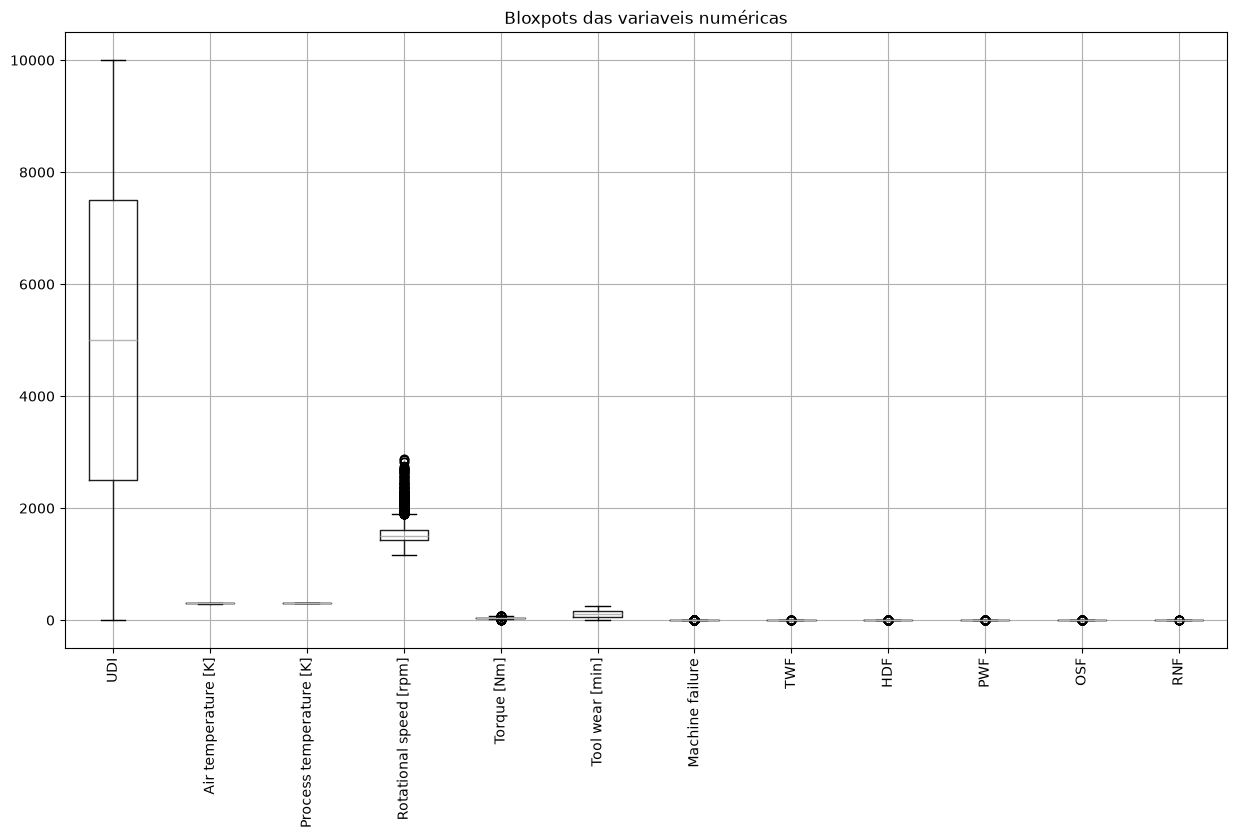

In [14]:
# Seleciona apenas colunas numericas da tabela

numeric_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,8 ))

df[numeric_columns].boxplot(rot=90)

plt.title('Bloxpots das variaveis numéricas')
plt.grid(True)
plt.show()

## 2. Preparação dos dados

In [15]:
# dividir o dataset em dois, uma parte com falha e outra sem falha
df_ok = df[df['Machine failure'] == 0]
df_fail = df[df['Machine failure'] == 1]

print(f'Quantidade maquinas sem falha: {len(df_ok)}')
print(f'Quantidade maquinas com falha: {len(df_fail)}')

Quantidade maquinas sem falha: 9661
Quantidade maquinas com falha: 339


In [16]:
# comparação de médias

comparacao = pd.DataFrame({
      "Sem falhas": df_ok.mean(numeric_only=True),
      "Com falhas": df_fail.mean(numeric_only=True)
})

comparacao 


,Sem falhas,Com falhas
UDI,5012.878791,4647.722714
Air temperature [K],299.973999,300.886431
Process temperature [K],309.995570,310.290265
Rotational speed [rpm],1540.260014,1496.486726
Torque [Nm],39.629655,50.168142
Tool wear [min],106.693717,143.781711
Machine failure,0.000000,1.000000
TWF,0.000000,0.135693
HDF,0.000000,0.339233
PWF,0.000000,0.280236


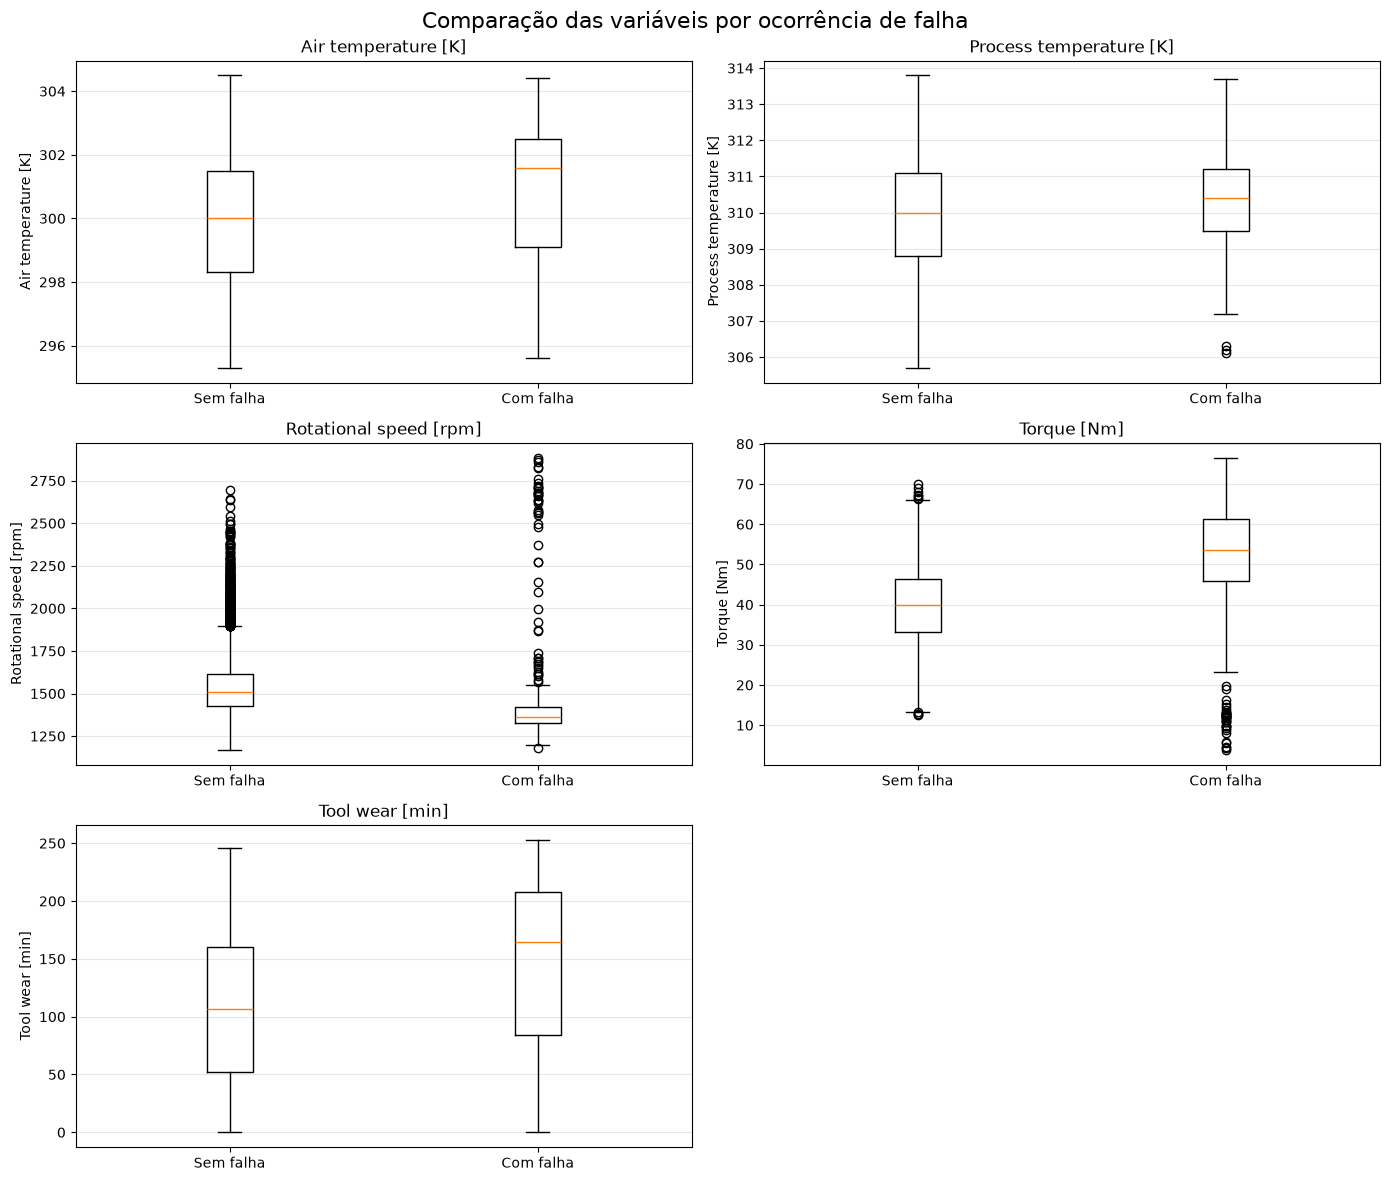

In [17]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, feature in enumerate(features):
    ax = axes[i // 2, i % 2]

    sem_falha = df.loc[df["Machine failure"] == 0, feature]
    com_falha = df.loc[df["Machine failure"] == 1, feature]

    ax.boxplot(
        [sem_falha, com_falha],
        tick_labels=["Sem falha", "Com falha"]
    )

    ax.set_title(feature)
    ax.set_ylabel(feature)
    ax.grid(axis="y", alpha=0.3)

# Remove o espaço vazio do sexto gráfico
axes[2, 1].remove()

plt.suptitle("Comparação das variáveis por ocorrência de falha", fontsize=16)
plt.tight_layout()
plt.show()

In [18]:
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

X = df[features]
y = df['Machine failure']

print("X:", X.shape)
print("y:", y.shape)

X: (10000, 5)
y: (10000,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treinamento:", X_train.shape)
print("Teste:", X_test.shape)

Treinamento: (8000, 5)
Teste: (2000, 5)


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Treinamento:", X_train_scaled.shape)
print("Teste:", X_test_scaled.shape)

Treinamento: (8000, 5)
Teste: (2000, 5)


# 3. Logistic Regression

In [21]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [22]:
y_pred = model.predict(X_test_scaled)

print('previsões:', y_pred.shape)
print(y_pred[:20])

previsões: (2000,)
[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


# 3.1 Avaliação inicial

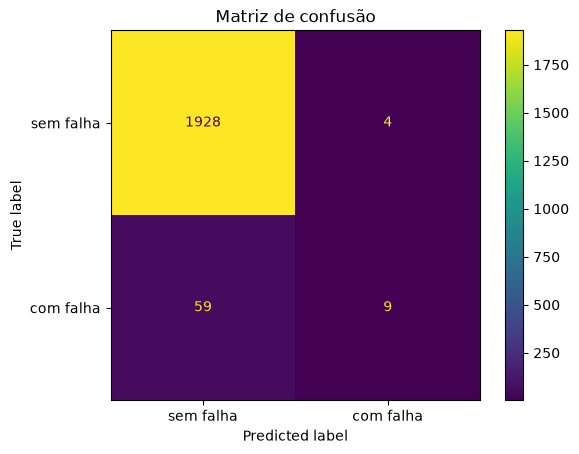

In [23]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['sem falha', 'com falha']

)

disp.plot()


plt.title('Matriz de confusão')
plt.show()

In [24]:
logistic_accuracy = accuracy_score(y_test, y_pred)
logistic_precision = precision_score(y_test, y_pred)
logistic_recall = recall_score(y_test, y_pred)
logistic_f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1-score:  {logistic_f1:.4f}")

Accuracy:  0.9685
Precision: 0.6923
Recall:    0.1324
F1-score:  0.2222


# 3.2 Logistic Regression balanceada

In [25]:
model_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

In [26]:
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)

print(f"Accuracy:  {accuracy_balanced:.4f}")
print(f"Precision: {precision_balanced:.4f}")
print(f"Recall:    {recall_balanced:.4f}")
print(f"F1-score:  {f1_balanced:.4f}")

Accuracy:  0.8210
Precision: 0.1411
Recall:    0.8382
F1-score:  0.2415


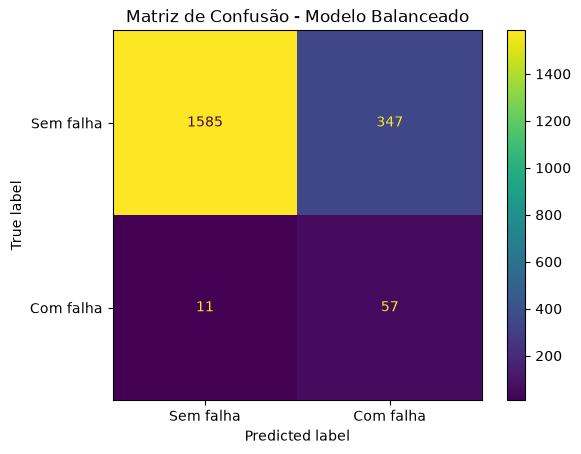

In [27]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

disp_balanced = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=["Sem falha", "Com falha"]
)

disp_balanced.plot()

plt.title("Matriz de Confusão - Modelo Balanceado")
plt.show()

In [28]:
y_prob = model_balanced.predict_proba(X_test_scaled)[:, 1]

print(y_prob[:20])

[0.96725355 0.49638428 0.64496584 0.01377921 0.89024043 0.70775131
 0.74562175 0.16679653 0.03501345 0.47108294 0.29844721 0.23916499
 0.03845488 0.22095167 0.26668617 0.61257686 0.18364907 0.73097678
 0.01709616 0.24331722]


# 3.3 Teste de thresholds

In [29]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print()

Threshold: 0.3
Precision: 0.0912
Recall:    0.9265
F1-score:  0.1660

Threshold: 0.4
Precision: 0.1152
Recall:    0.8676
F1-score:  0.2034

Threshold: 0.5
Precision: 0.1411
Recall:    0.8382
F1-score:  0.2415

Threshold: 0.6
Precision: 0.1711
Recall:    0.7647
F1-score:  0.2796

Threshold: 0.7
Precision: 0.2322
Recall:    0.7206
F1-score:  0.3513



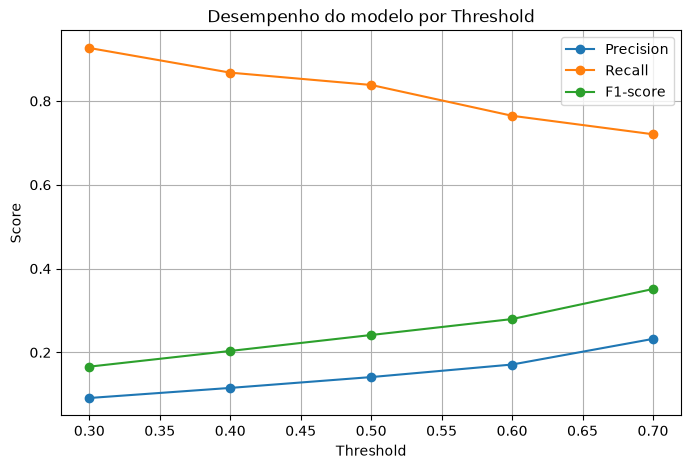

In [30]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precisions.append(precision_score(y_test, y_pred_threshold))
    recalls.append(recall_score(y_test, y_pred_threshold))
    f1_scores.append(f1_score(y_test, y_pred_threshold))

plt.figure(figsize=(8, 5))

plt.plot(thresholds, precisions, marker='o', label='Precision')
plt.plot(thresholds, recalls, marker='o', label='Recall')
plt.plot(thresholds, f1_scores, marker='o', label='F1-score')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Desempenho do modelo por Threshold')
plt.legend()
plt.grid(True)

plt.show()

In [31]:
thresholds_fine = np.arange(0.30, 0.91, 0.01)

results = []

for threshold in thresholds_fine:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

results_df = pd.DataFrame(results)

results_df.sort_values('f1', ascending=False).head(10)

,threshold,precision,recall,f1
54,0.84,0.376344,0.514706,0.434783
55,0.85,0.382022,0.500000,0.433121
53,0.83,0.363636,0.529412,0.431138
58,0.88,0.432836,0.426471,0.429630
56,0.86,0.390244,0.470588,0.426667
59,0.89,0.457627,0.397059,0.425197
51,0.81,0.336207,0.573529,0.423913
57,0.87,0.405405,0.441176,0.422535
52,0.82,0.342857,0.529412,0.416185
50,0.80,0.325000,0.573529,0.414894


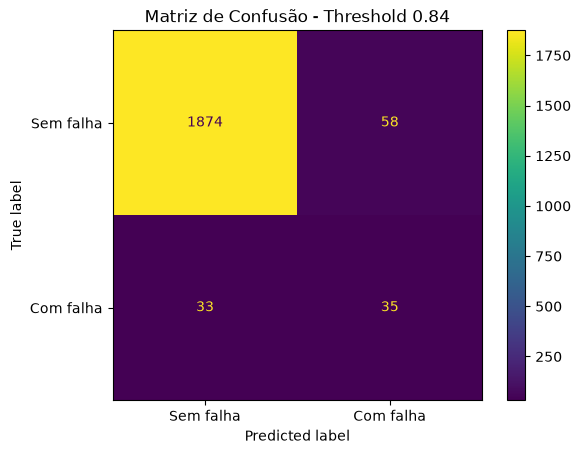

In [32]:
threshold_final = 0.84

y_pred_final = (y_prob >= threshold_final).astype(int)

cm_final = confusion_matrix(y_test, y_pred_final)

disp_final = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Sem falha", "Com falha"]
)

disp_final.plot()

plt.title("Matriz de Confusão - Threshold 0.84")
plt.show()

In [33]:
results_recall = results_df[results_df['recall'] >= 0.70]

results_recall.sort_values(
    'f1',
    ascending=False
).head(10)

,threshold,precision,recall,f1
42,0.72,0.253968,0.705882,0.373541
41,0.71,0.243781,0.720588,0.364312
40,0.70,0.232227,0.720588,0.351254
39,0.69,0.224771,0.720588,0.342657
38,0.68,0.223214,0.735294,0.342466
37,0.67,0.217949,0.750000,0.337748
36,0.66,0.214286,0.750000,0.333333
35,0.65,0.208163,0.750000,0.325879
34,0.64,0.195402,0.750000,0.310030
33,0.63,0.187500,0.750000,0.300000


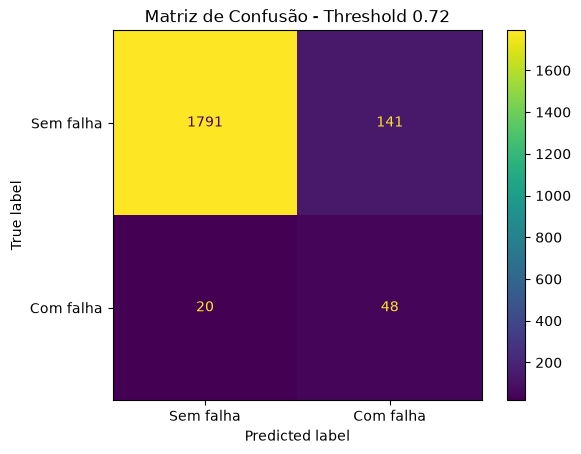

In [34]:
threshold_final = 0.72

y_pred_final = (y_prob >= threshold_final).astype(int)

cm_final = confusion_matrix(y_test, y_pred_final)

disp_final = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Sem falha", "Com falha"]
)

disp_final.plot()

plt.title("Matriz de Confusão - Threshold 0.72")
plt.show()

# 4. Random Forest

In [35]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [36]:
y_pred_rf = rf_model.predict(X_test)

print("Previsões:", y_pred_rf.shape)
print(y_pred_rf[:20])

Previsões: (2000,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [37]:
print(pd.Series(y_pred_rf).value_counts())

0    1933
1      67
Name: count, dtype: int64


# 4.1 Avaliação inicial

In [38]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy: ", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall:   ", round(recall_rf, 4))
print("F1-score: ", round(f1_rf, 4))

Accuracy:  0.9815
Precision: 0.7313
Recall:    0.7206
F1-score:  0.7259


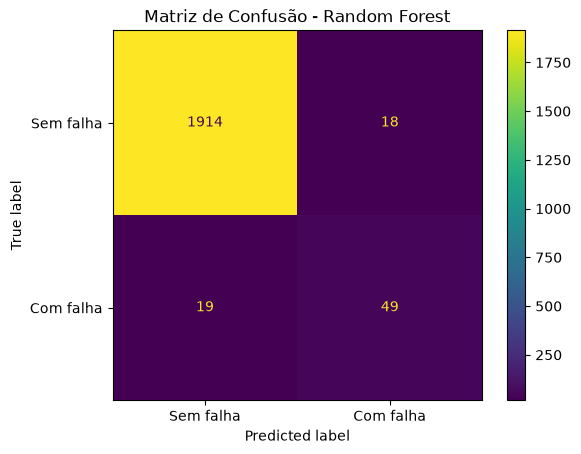

In [39]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Sem falha', 'Com falha']
)

disp.plot(cmap='viridis')

plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

In [40]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print(y_prob_rf[:20])

[0.35  0.    0.135 0.    0.06  0.    0.015 0.    0.    0.095 0.    0.005
 0.    0.    0.    0.    0.    0.37  0.005 0.   ]


# 4.2 Teste de thresholds

In [41]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:

    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    threshold_precision = precision_score(y_test, y_pred_threshold)
    threshold_recall = recall_score(y_test, y_pred_threshold)
    threshold_f1 = f1_score(y_test, y_pred_threshold)

    print(f"Threshold: {threshold}")
    print(f"Precision: {threshold_precision:.4f}")
    print(f"Recall:    {threshold_recall:.4f}")
    print(f"F1-score:  {threshold_f1:.4f}")
    print()

Threshold: 0.3
Precision: 0.4872
Recall:    0.8382
F1-score:  0.6162

Threshold: 0.4
Precision: 0.6071
Recall:    0.7500
F1-score:  0.6711

Threshold: 0.5
Precision: 0.7313
Recall:    0.7206
F1-score:  0.7259

Threshold: 0.6
Precision: 0.8491
Recall:    0.6618
F1-score:  0.7438

Threshold: 0.7
Precision: 0.8182
Recall:    0.5294
F1-score:  0.6429



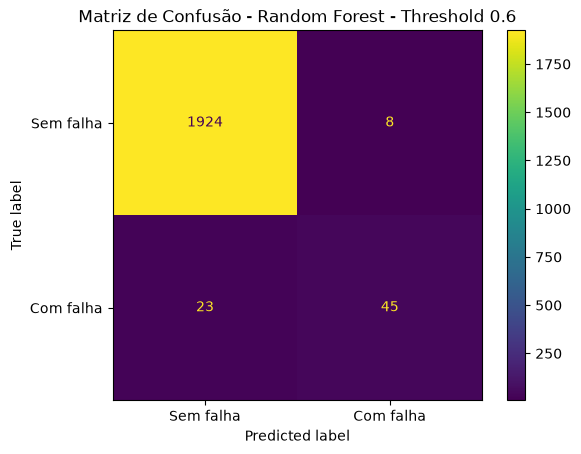

In [42]:
threshold = 0.6

y_pred_rf_06 = (y_prob_rf >= threshold).astype(int)

cm_rf_06 = confusion_matrix(y_test, y_pred_rf_06)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_06,
    display_labels=['Sem falha', 'Com falha']
).plot()

plt.title('Matriz de Confusão - Random Forest - Threshold 0.6')
plt.show()

In [43]:
y_prob_logistic = model.predict_proba(X_test_scaled)[:, 1]

y_pred_logistic_072 = (y_prob_logistic >= 0.72).astype(int)

logistic_072_accuracy = accuracy_score(y_test, y_pred_logistic_072)
logistic_072_precision = precision_score(y_test, y_pred_logistic_072)
logistic_072_recall = recall_score(y_test, y_pred_logistic_072)
logistic_072_f1 = f1_score(y_test, y_pred_logistic_072)

print("Logistic Regression - Threshold 0.72")
print(f"Accuracy:  {logistic_072_accuracy:.4f}")
print(f"Precision: {logistic_072_precision:.4f}")
print(f"Recall:    {logistic_072_recall:.4f}")
print(f"F1-score:  {logistic_072_f1:.4f}")

Logistic Regression - Threshold 0.72
Accuracy:  0.9690
Precision: 1.0000
Recall:    0.0882
F1-score:  0.1622


# Logistic Regression Balanceada

Nesta etapa, utilizamos `class_weight="balanced"` para lidar com o forte desbalanceamento entre as classes de falha e não falha.

In [44]:
y_pred_balanced = model_balanced.predict(X_test_scaled)

balanced_accuracy = accuracy_score(y_test, y_pred_balanced)
balanced_precision = precision_score(y_test, y_pred_balanced)
balanced_recall = recall_score(y_test, y_pred_balanced)
balanced_f1 = f1_score(y_test, y_pred_balanced)

print("Logistic Regression - Balanced")
print(f"Accuracy:  {balanced_accuracy:.4f}")
print(f"Precision: {balanced_precision:.4f}")
print(f"Recall:    {balanced_recall:.4f}")
print(f"F1-score:  {balanced_f1:.4f}")

Logistic Regression - Balanced
Accuracy:  0.8210
Precision: 0.1411
Recall:    0.8382
F1-score:  0.2415


## Comparação dos modelos

Nesta etapa, comparamos as diferentes configurações avaliadas utilizando Accuracy, Precision, Recall e F1-score.

O objetivo principal é avaliar a capacidade dos modelos de identificar corretamente as falhas, considerando o forte desbalanceamento entre as classes.

In [45]:
# Logistic Regression
logistic_accuracy = accuracy_score(y_test, y_pred)
logistic_precision = precision_score(y_test, y_pred)
logistic_recall = recall_score(y_test, y_pred)
logistic_f1 = f1_score(y_test, y_pred)


# Logistic Regression Balanceada
balanced_accuracy = accuracy_score(y_test, y_pred_balanced)
balanced_precision = precision_score(y_test, y_pred_balanced)
balanced_recall = recall_score(y_test, y_pred_balanced)
balanced_f1 = f1_score(y_test, y_pred_balanced)


# Random Forest - Threshold 0.5
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)


# Random Forest - Threshold 0.6
rf_06_accuracy = accuracy_score(y_test, y_pred_rf_06)
rf_06_precision = precision_score(y_test, y_pred_rf_06)
rf_06_recall = recall_score(y_test, y_pred_rf_06)
rf_06_f1 = f1_score(y_test, y_pred_rf_06)

In [46]:
comparison_results = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Logistic Regression - Balanced',
        'Random Forest - Threshold 0.5',
        'Random Forest - Threshold 0.6'
    ],
    
    'Accuracy': [
        logistic_accuracy,
        balanced_accuracy,
        rf_accuracy,
        rf_06_accuracy
    ],
    
    'Precision': [
        logistic_precision,
        balanced_precision,
        rf_precision,
        rf_06_precision
    ],
    
    'Recall': [
        logistic_recall,
        balanced_recall,
        rf_recall,
        rf_06_recall
    ],
    
    'F1-score': [
        logistic_f1,
        balanced_f1,
        rf_f1,
        rf_06_f1
    ]
})

comparison_results.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.9685,0.6923,0.1324,0.2222
1,Logistic Regression - Balanced,0.8210,0.1411,0.8382,0.2415
2,Random Forest - Threshold 0.5,0.9815,0.7313,0.7206,0.7259
3,Random Forest - Threshold 0.6,0.9845,0.8491,0.6618,0.7438
